# 💓 Heart Disease Prediction using Machine Learning

## 📌 Project Overview

This project focuses on predicting the presence of heart disease in patients using machine learning techniques.  
We apply multiple classification algorithms and compare their performance to identify the most accurate model for prediction.

The models used in this project include:
- Logistic Regression
- Random Forest Classifier
- XGBoost Classifier

---

## 👥 Group Members

**Group # 3**

- Shaesta Saleem — DSAI231103043  

---

## 👩‍🏫 Instructor

Ms. Allah Rakhi Saman

## Step 1: Import Libraries

We will first import all the necessary Python libraries required for data analysis, preprocessing, and model building.

In [1]:
# Importing necessary libraries

import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning models
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

# Evaluation metrics
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# To ignore warnings
import warnings
warnings.filterwarnings('ignore')

# 📂 Step 2: Load the Dataset

In this step, we will load the heart disease dataset and take a quick look at:
- First 5 rows of the data
- Shape of dataset
- Basic information about columns

This helps us understand the structure of our data before preprocessing.

In [2]:
# Load dataset
df = pd.read_csv("heart_disease_uci.csv")  # make sure file name matches your downloaded dataset

# Display first 5 rows
print("First 5 rows of dataset:")
display(df.head())

# Shape of dataset
print("\nDataset Shape:", df.shape)

# Basic info
print("\nDataset Info:")
df.info()

# Check missing values
print("\nMissing Values in Each Column:")
print(df.isnull().sum())

First 5 rows of dataset:


,id,age,sex,dataset,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,ca,thal,num
0,1,63,Male,Cleveland,typical angina,145.0,233.0,True,lv hypertrophy,150.0,False,2.3,downsloping,0.0,fixed defect,0
1,2,67,Male,Cleveland,asymptomatic,160.0,286.0,False,lv hypertrophy,108.0,True,1.5,flat,3.0,normal,2
2,3,67,Male,Cleveland,asymptomatic,120.0,229.0,False,lv hypertrophy,129.0,True,2.6,flat,2.0,reversable defect,1
3,4,37,Male,Cleveland,non-anginal,130.0,250.0,False,normal,187.0,False,3.5,downsloping,0.0,normal,0
4,5,41,Female,Cleveland,atypical angina,130.0,204.0,False,lv hypertrophy,172.0,False,1.4,upsloping,0.0,normal,0



Dataset Shape: (920, 16)

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 920 entries, 0 to 919
Data columns (total 16 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   id        920 non-null    int64  
 1   age       920 non-null    int64  
 2   sex       920 non-null    object 
 3   dataset   920 non-null    object 
 4   cp        920 non-null    object 
 5   trestbps  861 non-null    float64
 6   chol      890 non-null    float64
 7   fbs       830 non-null    object 
 8   restecg   918 non-null    object 
 9   thalch    865 non-null    float64
 10  exang     865 non-null    object 
 11  oldpeak   858 non-null    float64
 12  slope     611 non-null    object 
 13  ca        309 non-null    float64
 14  thal      434 non-null    object 
 15  num       920 non-null    int64  
dtypes: float64(5), int64(3), object(8)
memory usage: 115.1+ KB

Missing Values in Each Column:
id            0
age           0
sex           0
dataset 

# 📊 Step 3: Data Exploration & Visualization

In this step, we will explore the dataset to understand:
- Target variable distribution (`num`)
- Age distribution of patients
- Relationship between numerical features
- Missing data impact overview

This dataset contains real-world missing values, so visualization helps us understand data quality before preprocessing.

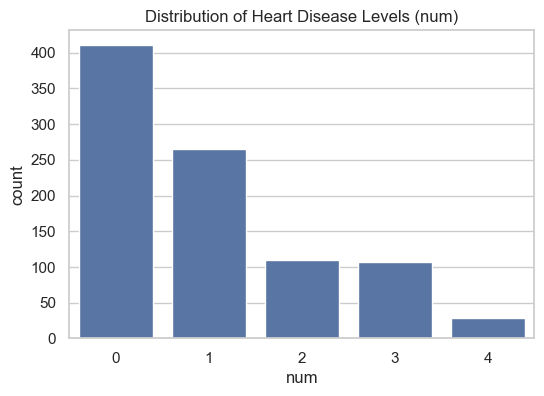

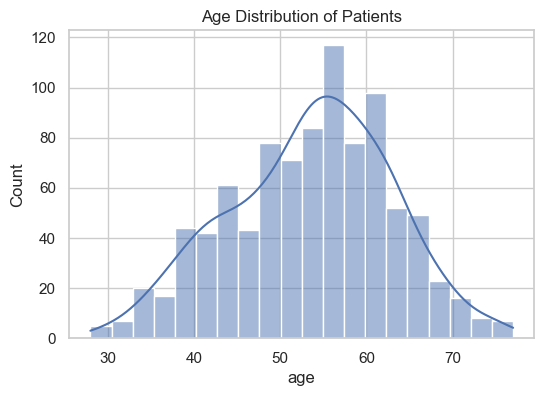

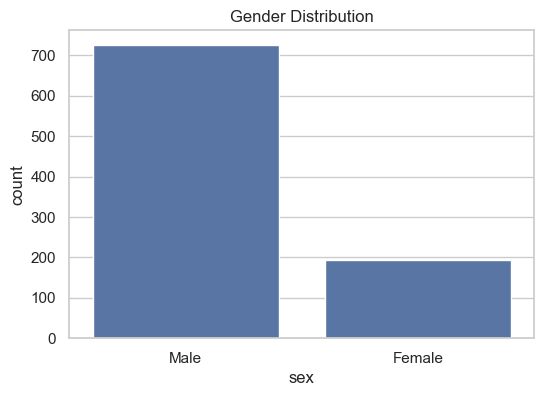

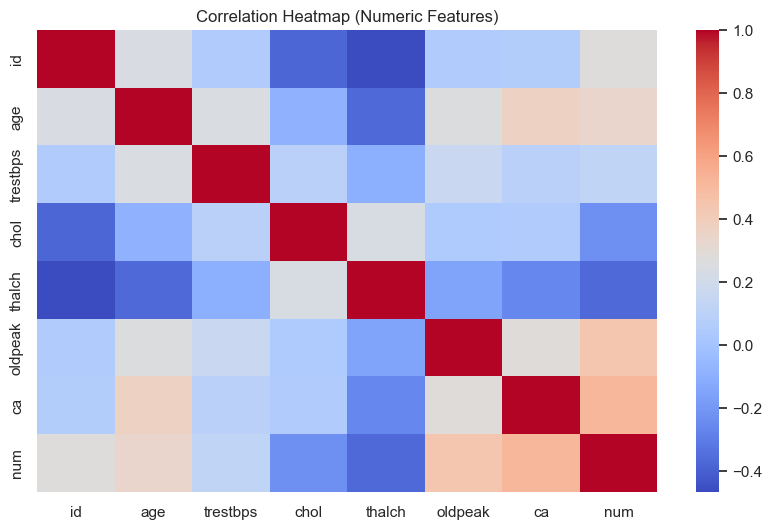

In [3]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")

# 🔹 1. Target variable distribution (num = disease level)
plt.figure(figsize=(6,4))
sns.countplot(x='num', data=df)
plt.title("Distribution of Heart Disease Levels (num)")
plt.show()

# 🔹 2. Age distribution
plt.figure(figsize=(6,4))
sns.histplot(df['age'], bins=20, kde=True)
plt.title("Age Distribution of Patients")
plt.show()

# 🔹 3. Sex distribution
plt.figure(figsize=(6,4))
sns.countplot(x='sex', data=df)
plt.title("Gender Distribution")
plt.show()

# 🔹 4. Correlation heatmap (numeric only)
plt.figure(figsize=(10,6))
sns.heatmap(df.select_dtypes(include=['int64','float64']).corr(),
            cmap="coolwarm", annot=False)
plt.title("Correlation Heatmap (Numeric Features)")
plt.show()

In [4]:
# Convert multi-class target into binary classification
df['target'] = (df['num'] > 0).astype(int)

# Check result
print(df['target'].value_counts())

target
1    509
0    411
Name: count, dtype: int64


# 🧹 Step 4: Data Cleaning & Preprocessing

In this step, we will:
- Handle missing values
- Select important features
- Prepare dataset for machine learning models

Since this dataset contains real-world missing data, proper cleaning is necessary before training models.

In [5]:
# 🔹 1. Check missing values again
print("Missing values before cleaning:\n")
print(df.isnull().sum())

# 🔹 2. Fill missing values (numerical columns with median)
num_cols = ['trestbps', 'chol', 'thalch', 'oldpeak', 'ca']

for col in num_cols:
    df[col].fillna(df[col].median(), inplace=True)

# 🔹 3. Fill categorical missing values with mode
cat_cols = ['fbs', 'restecg', 'exang', 'slope', 'thal']

for col in cat_cols:
    df[col].fillna(df[col].mode()[0], inplace=True)

# 🔹 4. Drop unnecessary columns
df = df.drop(['id', 'dataset', 'num'], axis=1)

# 🔹 5. Final check
print("\nMissing values after cleaning:\n")
print(df.isnull().sum())

Missing values before cleaning:

id            0
age           0
sex           0
dataset       0
cp            0
trestbps     59
chol         30
fbs          90
restecg       2
thalch       55
exang        55
oldpeak      62
slope       309
ca          611
thal        486
num           0
target        0
dtype: int64

Missing values after cleaning:

age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalch      0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64


# 🔄 Step 5: Encoding & Train-Test Split

In this step, we will:
- Convert categorical features into numeric format using encoding
- Split dataset into training and testing sets

This is required because machine learning models only work with numerical data.

In [6]:
from sklearn.preprocessing import LabelEncoder

# 🔹 1. Encode categorical columns
cat_cols = df.select_dtypes(include='object').columns

le = LabelEncoder()

for col in cat_cols:
    df[col] = le.fit_transform(df[col])

# 🔹 2. Separate features and target
X = df.drop('target', axis=1)
y = df['target']

# 🔹 3. Train-test split
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# 🔹 4. Check shapes
print("Training set shape:", X_train.shape)
print("Testing set shape:", X_test.shape)

Training set shape: (736, 13)
Testing set shape: (184, 13)


# 🤖 Step 6: Model Training & Comparison

In this step, we will train three machine learning models:
- Logistic Regression (baseline model)
- Random Forest Classifier (ensemble model)
- XGBoost Classifier (advanced boosting model)

Then we will compare their performance using accuracy score to determine the best model for heart disease prediction.

In [7]:
!pip install xgboost

In [8]:
# 🔹 Import XGBoost
from xgboost import XGBClassifier

# =========================
# 1. Logistic Regression
# =========================
lr_model = LogisticRegression(max_iter=1000)
lr_model.fit(X_train, y_train)
y_pred_lr = lr_model.predict(X_test)
lr_acc = accuracy_score(y_test, y_pred_lr)

# =========================
# 2. Random Forest
# =========================
rf_model = RandomForestClassifier(random_state=42)
rf_model.fit(X_train, y_train)
y_pred_rf = rf_model.predict(X_test)
rf_acc = accuracy_score(y_test, y_pred_rf)

# =========================
# 3. XGBoost Model
# =========================
xgb_model = XGBClassifier(use_label_encoder=False, eval_metric='logloss')
xgb_model.fit(X_train, y_train)
y_pred_xgb = xgb_model.predict(X_test)
xgb_acc = accuracy_score(y_test, y_pred_xgb)

# =========================
# Results
# =========================
print("📊 Model Accuracies:\n")
print("Logistic Regression Accuracy:", lr_acc)
print("Random Forest Accuracy:", rf_acc)
print("XGBoost Accuracy:", xgb_acc)

📊 Model Accuracies:

Logistic Regression Accuracy: 0.7880434782608695
Random Forest Accuracy: 0.8369565217391305
XGBoost Accuracy: 0.8586956521739131


# 📊 Step 7: Model Evaluation (Confusion Matrix & Report)

In this step, we will evaluate the best performing model (XGBoost) using:
- Confusion Matrix
- Classification Report (Precision, Recall, F1-score)

This gives a deeper understanding of model performance beyond accuracy.

Confusion Matrix:
 [[67  8]
 [18 91]]


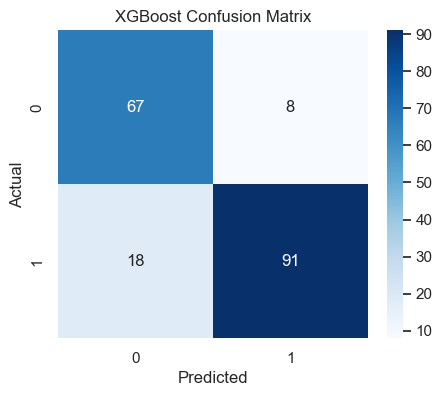


Classification Report:

              precision    recall  f1-score   support

           0       0.79      0.89      0.84        75
           1       0.92      0.83      0.88       109

    accuracy                           0.86       184
   macro avg       0.85      0.86      0.86       184
weighted avg       0.87      0.86      0.86       184



In [9]:
from sklearn.metrics import confusion_matrix, classification_report

# =========================
# Confusion Matrix (XGBoost)
# =========================
cm = confusion_matrix(y_test, y_pred_xgb)

print("Confusion Matrix:\n", cm)

# Visualize Confusion Matrix
plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("XGBoost Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# =========================
# Classification Report
# =========================
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred_xgb))

# 📊 Final Model Comparison

In this step, we compare all trained models side by side using:
- Accuracy Score
- Visual Bar Chart

This helps us clearly identify the best performing model for heart disease prediction.

📊 Final Model Accuracies:

Logistic Regression: 0.7880434782608695
Random Forest: 0.8369565217391305
XGBoost: 0.8586956521739131


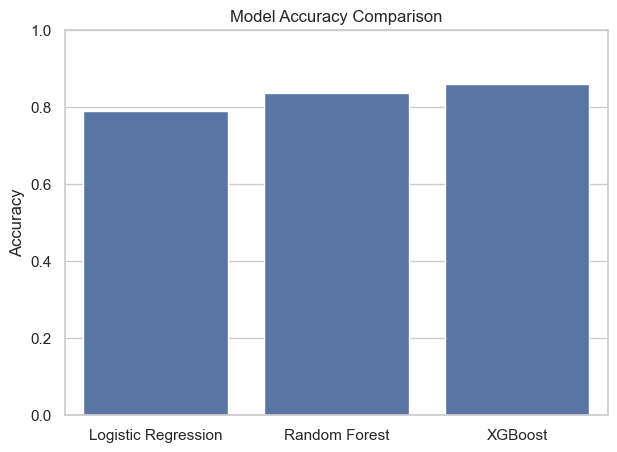

In [10]:
# 📊 Print all accuracies together
print("📊 Final Model Accuracies:\n")

print("Logistic Regression:", lr_acc)
print("Random Forest:", rf_acc)
print("XGBoost:", xgb_acc)

# =========================
# Bar Chart Comparison
# =========================
models = ['Logistic Regression', 'Random Forest', 'XGBoost']
accuracies = [lr_acc, rf_acc, xgb_acc]

plt.figure(figsize=(7,5))
sns.barplot(x=models, y=accuracies)

plt.title("Model Accuracy Comparison")
plt.ylabel("Accuracy")
plt.ylim(0, 1)

plt.show()

# 📊 Confusion Matrix Comparison

In this step, we visualize confusion matrices for all three models:
- Logistic Regression
- Random Forest
- XGBoost

This helps us understand how each model performs in terms of correct and incorrect predictions.

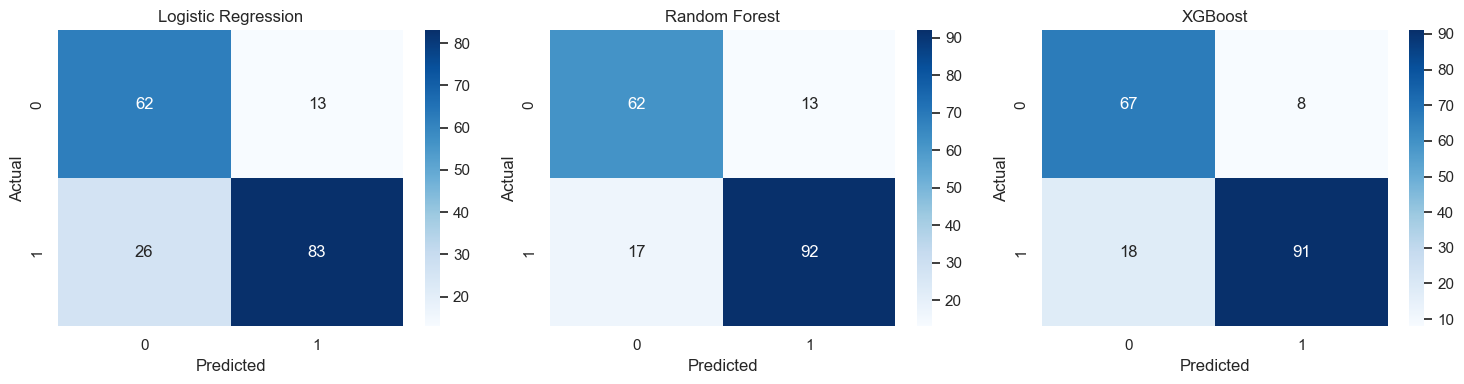

In [11]:
from sklearn.metrics import confusion_matrix

models = {
    "Logistic Regression": y_pred_lr,
    "Random Forest": y_pred_rf,
    "XGBoost": y_pred_xgb
}

plt.figure(figsize=(15, 4))

for i, (name, y_pred) in enumerate(models.items(), 1):
    cm = confusion_matrix(y_test, y_pred)
    
    plt.subplot(1, 3, i)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.title(name)
    plt.xlabel("Predicted")
    plt.ylabel("Actual")

plt.tight_layout()
plt.show()

# 💾 Step 8: Save Model & Make Predictions

In this step, we will:
- Save the trained best model (XGBoost)
- Load it later for prediction
- Make predictions on new unseen data

This makes our model reusable for real-world applications.

In [12]:
import joblib

# Save the best model (XGBoost)
joblib.dump(xgb_model, "heart_disease_model.pkl")

print("✅ Model saved successfully as heart_disease_model.pkl")

✅ Model saved successfully as heart_disease_model.pkl


In [13]:
# Load the saved model
loaded_model = joblib.load("heart_disease_model.pkl")

# Example: new patient data (same order as training features!)
sample_data = X_test.iloc[0].values.reshape(1, -1)

# Prediction
prediction = loaded_model.predict(sample_data)

if prediction[0] == 1:
    print("⚠️ Patient has risk of heart disease")
else:
    print("✅ Patient is healthy")

✅ Patient is healthy
